# Training an FNO on Darcy-Flow in Neuromancer

This tutorial demonstrates the use of [FNOs](https://neuraloperator.github.io/dev/theory_guide/fno.html) for solving partial differential equations (PDEs) in the Neuromancer library.

This tutorial demonstrates the complete workflow of training a neural operator: 
1. Loading and preprocessing the Darcy-Flow dataset, wrapping in Neuromancer DictDataset
2. Creating an FNO model architecture using the `neuralop` library
3. Setting up `neuromancer.problem.Problem`, adding H1/L2 losses as `neuromancer.loss.PenaltyLoss`
4. Training the model with Neuromancer `Trainer`
5. Evaluating predictions and zero-shot super-resolution

We utilize the neuralop library with two specific architectural choices:
1. Single-Channel FNO: We process the input $\mathbf{K}$ and predict $\mathbf{P}$ as 2D scalar fields ($1 \to 1$ channel). This setup is efficient and directly mirrors the physical mapping.
2. Implicit Grid Information: We do not use explicit grid embeddings (coordinate features). Why? The FNO operates in the Fourier domain. Since the Darcy PDE is solved on a structured grid, the Fourier transform inherently captures spatial relationships and global dependencies through its basis functions, making manual $(x, y)$ coordinates redundant for this task.

Example inspiration: https://neuraloperator.github.io/dev/auto_examples/models/plot_FNO_darcy.html

### References

[1] [FNO theory guide - neuralop library](https://neuraloperator.github.io/dev/theory_guide/fno.html)

[2] [neuralop library - FNO Darcy Flow example](https://neuraloperator.github.io/dev/auto_examples/models/plot_FNO_darcy.html)

[4] [NVIDIA FNO Darcy Flow example](https://docs.nvidia.com/physicsnemo/25.08/physicsnemo-sym/user_guide/neural_operators/darcy_fno.html#darcy-flow-with-fourier-neural-operator)


## Problem Description

Darcy’s law describes the flow rate of a fluid through a porous medium. We consider the steady-state pressure field in a 2D domain, governed by the following second-order elliptic PDE:

$$-\nabla \cdot \bigl(k(\mathbf{x}) \nabla p(\mathbf{x})\bigr) = f(\mathbf{x}), \quad \mathbf{x} \in D$$

Where:
* $p(\mathbf{x})$ is the pressure field.
* $k(\mathbf{x})$ is the permeability coefficient.
* $f(\mathbf{x})$ is the forcing function (source term).

For simplicity, the dynamic viscosity term ($\mu$) is omitted without loss of generality.

### Problem Setup & Data
To train the neural operator, we define the specific domain, boundary conditions, and input/output mapping as follows:

* **Spatial Domain:** The 2D unit square, $D = \{(x, y) \in (0, 1)^2\}$.
* **Boundary Conditions:** Homogeneous Dirichlet boundaries, $p(\mathbf{x}) = 0$ for all $\mathbf{x} \in \partial D$.
* **Input ($k$):** The permeability field, discretized as a grid $\mathbf{K} \in \mathbb{R}^{n \times n}$.
* **Output ($p$):** The resulting pressure field, discretized as a grid $\mathbf{P} \in \mathbb{R}^{n \times n}$.

## Surrogate Learning Task

The goal is to learn the operator mapping $\mathcal{G}: k \mapsto p$ using a dataset of discretized fields.

FNO requires structured Euclidean grid inputs of the form $D = \{\mathbf{x}_i\}$ for $i \in \mathbb{N}^{n \times n}$, so both the permeability ($k(\mathbf{x})$) and pressure ($p(\mathbf{x})$) fields are discretized as 2D grids $\mathbf{K},\mathbf{P} \in \mathbb{R}^{n \times n}$.

Unlike standard solvers that find $p$ for a single $k$, the FNO learns the solution operator for a **distribution** of permeability fields $\mathbf{K} \sim \mu$. The model learns to predict the pressure response for any new permeability input within the distribution:

$$\mathbf{K} \mapsto \mathbf{P}$$

## Install (Colab only)
Skip this step when running locally.

In [1]:
# !pip install neuromancer
# !pip install pyDOE

*Note: When running on Colab, one might encounter a pip dependency error with Lida 0.0.10. This can be ignored*

## Imports

In [2]:
# torch and numpy imports
import torch
import torch.nn as nn
import numpy as np

# plotting imports
import matplotlib.pyplot as plt

# filter some user warnings from torch broadcast
import warnings

warnings.filterwarnings("ignore")


In [3]:
# Set default dtype to float32
torch.set_default_dtype(torch.float)
# PyTorch random number generator
torch.manual_seed(1234)

# Random number generators in other libraries
np.random.seed(1234)

# Device configuration
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: cuda


### Get data of the exact solution
- Data source: (https://zenodo.org/records/12784353)
- Select the number of training grids (`n_train`) at a given resolution (`train_resolution`) (16X16)
- Select the number of testing grids (`n_tests`) at various resolutions (`test_resolutions`) (16X16, 32x32)
- Download if needed, save it in `./data/darcy_flow_small/`

In [4]:
from neuralop.data.datasets import DarcyDataset

dataset = DarcyDataset(
    root_dir="./data/darcy_flow_small/",
    n_train=20,
    n_tests=[10, 10],
    batch_size=4,
    test_batch_sizes=[4, 2],
    train_resolution=16,
    test_resolutions=[16, 32],
    download=True,
)

print(dataset.__dict__.keys())  # check available keys in dataset

Loading test db for resolution 16 with 10 samples 
Loading test db for resolution 32 with 10 samples 
dict_keys(['root_dir', 'batch_size', 'test_resolutions', 'test_batch_sizes', '_train_db', '_data_processor', '_test_dbs'])


Displaying sizes for the 16x16 testing grid

In [5]:
train_db = dataset._train_db
print((train_db.__dict__.keys()))  # check available keys in dataset
# Get dataset length and grid resolution
n_train = len(train_db)
index = 0
x_sample = train_db[index]["x"]  # shape (1, 16, 16) for one snapshot of data
res_x, res_y = x_sample.shape[-2:]  # grid resolution

print(f"length of training set = {n_train}")
print(f"resolution = {res_x}")
print(f"shape of grid = [{res_x}, {res_y}]")


dict_keys(['x', 'y', 'transform_x', 'transform_y'])
length of training set = 20
resolution = 16
shape of grid = [16, 16]


Displaying sizes for the 32x32 testing grid

In [6]:
test_db = dataset._test_dbs[32]  # use 16,32 etc
print((test_db.__dict__.keys()))  # check available keys in dataset
# Get dataset length and grid resolution
n_train = len(test_db)

index = 0
x_sample = test_db[index]["x"]  # shape (1, 16, 16) for your data
res_x, res_y = x_sample.shape[-2:]  # grid resolution

print(f"length of training set = {n_train}")
print(f"resolution = {res_x}")
print(f"shape of grid = [{res_x}, {res_y}]")

dict_keys(['x', 'y', 'transform_x', 'transform_y'])
length of training set = 10
resolution = 32
shape of grid = [32, 32]


### Visualise dataset
We can see how the positional embedding adds coordinate information to our input data. This helps the neural operator understand spatial relationships in the data.
Not necessarly need to use this for the input grid

In [7]:
from neuralop.layers.embeddings import GridEmbedding2D

# Which sample to view
index = 0

data = train_db[index]
data = dataset.data_processor.preprocess(data, batched=False)

# The first step of the default FNO model is a grid-based
# positional embedding. We will add it manually here to
# visualize the channels appended by this embedding.
positional_embedding = GridEmbedding2D(in_channels=1)
# At train time, data will be collated with a batch dimension.
# We create a batch dimension to pass into the embedding, then re-squeeze
x = positional_embedding(data["x"].unsqueeze(0)).squeeze(0)
y = data["y"]

/tmp/ipykernel_263851/2254824060.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


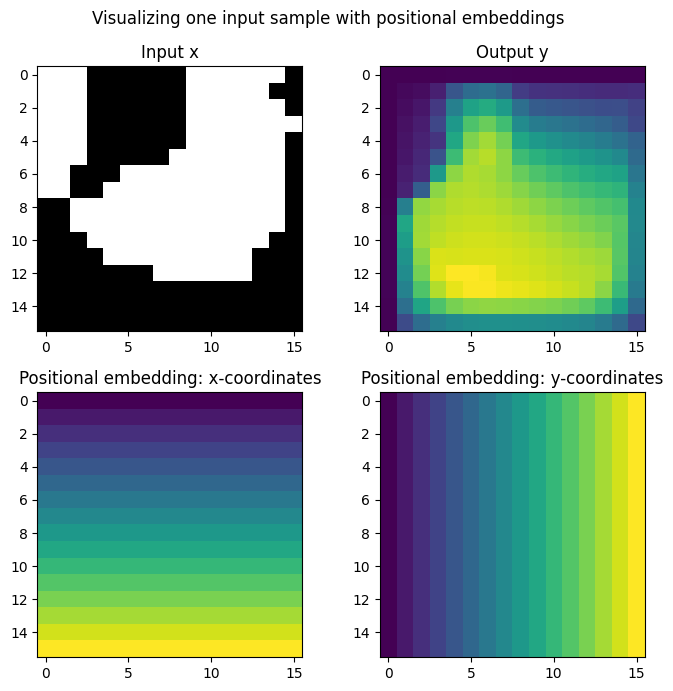

In [8]:
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(2, 2, 1)
ax.imshow(x[0], cmap="gray")
ax.set_title("Input x")
ax = fig.add_subplot(2, 2, 2)
ax.imshow(y.squeeze())
ax.set_title("Output y")
ax = fig.add_subplot(2, 2, 3)
ax.imshow(x[1])
ax.set_title("Positional embedding: x-coordinates")
ax = fig.add_subplot(2, 2, 4)
ax.imshow(x[2])
ax.set_title("Positional embedding: y-coordinates")
fig.suptitle("Visualizing one input sample with positional embeddings", y=0.98)
plt.tight_layout()
fig.show()

### Create Neuromancer datasets for FNO

In [9]:
from neuromancer.dataset import DictDataset

batch_size_train = 4

# Stack the samples (apply the same preprocessing if you need it)
xs, ys = [], []
for i in range(len(dataset._train_db)):
    sample = dataset.data_processor.preprocess(dataset._train_db[i], batched=False)
    xs.append(sample["x"])
    ys.append(sample["y"].squeeze(0))  # [1, H, W]
x_train = torch.stack(xs)  # [N, 1, 16, 16]
y_train = torch.stack(ys)  # [N, 1, H, W]

# send to device
x_train = x_train.to(device)
y_train = y_train.to(device)
# turn on gradients for FNO
x_train.requires_grad = True
y_train.requires_grad = True

train_ds_fno = DictDataset({"x_grid": x_train, "y_grid": y_train}, name="train")
train_loader_fno = torch.utils.data.DataLoader(
    train_ds_fno,
    batch_size=batch_size_train,
    shuffle=True,
    collate_fn=train_ds_fno.collate_fn,
)

# Example test loader (pick one resolution index)
res = 32  # 16 or 32
batch_size_test = 4
xs_t, ys_t = [], []
for i in range(len(dataset.test_dbs[res])):
    sample = dataset.data_processor.preprocess(dataset.test_dbs[res][i], batched=False)
    xs_t.append(sample["x"])
    ys_t.append(sample["y"].squeeze(0))  # [1, H, W]

x_test = torch.stack(xs_t)  # [N, 1, 16, 16]
y_test = torch.stack(ys_t)  # [N, 1, H, W]

test_ds_fno = DictDataset({"x_grid": x_test, "y_grid": y_test}, name=f"test{res}")
test_loader_fno = torch.utils.data.DataLoader(
    test_ds_fno,
    batch_size=batch_size_test,  # match your test batch size
    shuffle=False,
    collate_fn=test_ds_fno.collate_fn,
)

## Dimensionality checks for data

In [10]:
s = dataset.data_processor.preprocess(dataset.test_dbs[res][0], batched=False)
print(s["x"].shape, s["y"].shape)

torch.Size([1, 32, 32]) torch.Size([1, 1, 32, 32])


In [11]:
s = dataset.data_processor.preprocess(dataset._train_db[0], batched=False)
print(s["x"].shape, s["y"].shape)

torch.Size([1, 16, 16]) torch.Size([1, 1, 16, 16])


In [12]:
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

torch.Size([20, 1, 16, 16]) torch.Size([20, 1, 16, 16])
torch.Size([10, 1, 32, 32]) torch.Size([10, 1, 32, 32])


### FNO added from neuralop library
Added a wrapper in (`src/neuromancer/modules/operators.py`) to provide model metadata in the correct format


In [13]:
# wrapper for neuralop.models import FNO
from neuromancer.modules.operators import FNO
from neuralop.utils import count_model_params
import sys

# FNO to to train the operator for the PDE problem bounded in the PDE domain
fno_model = FNO(
    n_modes=(8, 8),
    in_channels=1,
    out_channels=1,
    hidden_channels=12,
    projection_channel_ratio=2,
)
fno_model = fno_model.to(device)

# Count and display the number of parameters
n_params = count_model_params(fno_model)
print(f"\nOur model has {n_params} parameters.")
sys.stdout.flush()


Our model has 48133 parameters.


In [14]:
from neuromancer.system import Node

# symbolic wrapper of the FNO
fno_node = Node(fno_model, ["x_grid"], ["y_fno"], name="fno_model")

In [15]:
print("symbolic inputs  of the fno_node:", fno_node.input_keys)
print("symbolic outputs of the fno_node:", fno_node.output_keys)

symbolic inputs  of the fno_node: ['x_grid']
symbolic outputs of the fno_node: ['y_fno']


In [16]:
# check device for train data
print(train_ds_fno.datadict["y_grid"].device)
# Check shapes match (Input vs Forward Pass Output)
print(f"Input training shape: {train_ds_fno.datadict['y_grid'].shape}")
print(
    f"Forward Pass on Train data shape: {fno_node(train_ds_fno.datadict)['y_fno'].shape}"
)

cuda:0
Input training shape: torch.Size([20, 1, 16, 16])
Forward Pass on Train data shape: torch.Size([20, 1, 16, 16])


# Generate H1 and L2 loss for loss evaluation 
We use H1 loss for training and L2 loss for evaluation H1 loss is particularly good for PDE problems as it penalizes both function values and gradients

## L2 norm

$$
\|y - y_h\|_{L^2(\Omega)}^2.
$$

## H1 norm

$$
\|y - y_h\|_{H^1(\Omega)}^2
=
\|y - y_h\|_{L^2(\Omega)}^2
+
\|y_x - y_{h,x}\|_{L^2(\Omega)}^2
+
\|y_t - y_{h,t}\|_{L^2(\Omega)}^2.
$$

### Formulate L2 loss, H1 loss

Approach 1: Use a standard H1 loss python function and wrap it in the `neuromancer.constraint.Loss` object

In [17]:
from neuromancer.modules.operators import LpLoss, H1Loss
from neuromancer.constraint import Loss  # wrapper for neuromancer

h1_loss_fn = H1Loss(d=2)
l2_loss_fn = LpLoss(d=2, p=2)

h1_obj = Loss(
    ["y_fno", "y_grid"],
    lambda yhat, y: h1_loss_fn(yhat.squeeze(1), y.squeeze(1)),
    name="h1_loss_fn",
)

l2_obj = Loss(
    ["y_fno", "y_grid"],
    lambda yhat, y: l2_loss_fn(yhat.squeeze(1), y.squeeze(1)),
    name="l2_loss_fn",
)

Approach 2: Formulate the H1 loss definition with simple Neuromancer wrappers

In [18]:
from neuromancer.constraint import variable

# Inputs from your datadict
y_true = variable("y_grid")  # B x C x H x W
y_hat_fno = variable("y_fno")  # B x C x H x W

# Finite forward differences
dx_hat = (
    y_hat_fno[..., 1:, :] - y_hat_fno[..., :-1, :]
)  # \hat{f}{x_{i+1},y_i} - \hat{f}_{x_i,y_i}
dx_true = y_true[..., 1:, :] - y_true[..., :-1, :]  # f(x_{i+1},y_i} - f_{x_i,y_i}

dy_hat = (
    y_hat_fno[..., :, 1:] - y_hat_fno[..., :, :-1]
)  # \hat{f}{x_i,y_{i+1}} - \hat{f}_{x_i,y_i}
dy_true = y_true[..., :, 1:] - y_true[..., :, :-1]  # f{x_i,y_{i+1}) - f_{x_i,y_i}

Apply constraints on `variable` 

In [19]:
# Value (L2) match and gradient (L2) matches; ^2 sets the L2 norm
val_constraint = (y_hat_fno == y_true) ^ 2
val_constraint.update_name("h1_value")

x_grad_constraint = (dx_hat == dx_true) ^ 2
x_grad_constraint.update_name("h1_dx")

y_grad_constraint = (dy_hat == dy_true) ^ 2
y_grad_constraint.update_name("h1_dy")

# To do: add weights, normalisation of gradient losses

Approach 3: Wrap the residuals with `Objective` and minimise 

In [20]:
from neuromancer.constraint import Objective

# Approach 2: Using Objective
residual_l2 = y_hat_fno - y_true
l2_obj = Objective(residual_l2**2, metric=torch.mean, name="l2_loss")

# Approach 2: Using Objective
residual_h1_dx = dx_hat - dx_true
h1_dx_obj = Objective(residual_h1_dx**2, metric=torch.mean, name="h1_dx_loss")

# Approach 2: Using Objective
residual_h1_dy = dy_hat - dy_true
h1_dy_obj = Objective(residual_h1_dy**2, metric=torch.mean, name="h1_dy_loss")

### Setup FNO problem and Trainer 

In [21]:
from neuromancer.loss import PenaltyLoss
from neuromancer.problem import Problem

# aggregate list of objective terms and constraints
# H1 loss (h1_obj) or L2 loss (l2_obj) for training FNO
# objectives_fno = [h1_obj]  #Approach 1
# objectives_fno = [val_constraint, x_grad_constraint, y_grad_constraint] #Approach 2
objectives_fno = [l2_obj, h1_dx_obj, h1_dy_obj]  # Approach 3
constraints_fno = []
# create constrained optimization loss
loss_fno = PenaltyLoss(objectives_fno, constraints_fno)

# construct the FNO supervised training problem
problem_fno = Problem(nodes=[fno_node], loss=loss_fno)

### Show problem FNO

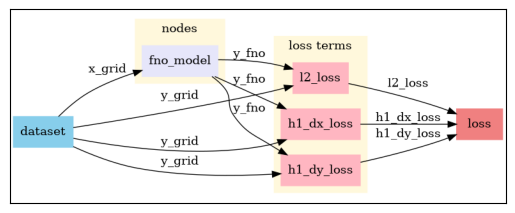

In [22]:
# Visualize the problem graph. Note: must have graphviz installed in the system
problem_fno.show()

### Train FNO purely data driven - using 20 samples of 16 x 16 data

In [23]:
from neuromancer.trainer import Trainer

optimizer = torch.optim.AdamW(problem_fno.parameters(), lr=1e-2, weight_decay=1e-4)
epochs = 50

#  Neuromancer trainer
trainer = Trainer(
    problem_fno.to(device),
    train_loader_fno,
    optimizer=optimizer,
    epochs=epochs,
    epoch_verbose=10,
    train_metric="train_loss",
    dev_metric="train_loss",
    eval_metric="train_loss",
    warmup=epochs,
    device=device,
)

In [24]:
# Train FNO
best_model = trainer.train()

# load best trained model
problem_fno.load_state_dict(best_model)

epoch: 0  train_loss: 1.3217754364013672
epoch: 10  train_loss: 0.21336741745471954
epoch: 20  train_loss: 0.07628743350505829
epoch: 30  train_loss: 0.0232708603143692
epoch: 40  train_loss: 0.015945101156830788


<All keys matched successfully>

## Visualizing predictions

### Zero-shot super-resolution evaluation
One of the key advantages of neural operators is their resolution invariance. We can test on 32 x 32 grid directly from a 16x16 training of the FNO

In [25]:
# evaluate trained FNO on test data
fno_out = problem_fno.nodes[0].cpu()
fno_model_out = fno_out(test_ds_fno.datadict)  # now on 32x32 grid

# evaluate forward pass on the train data
fno_model_out["y_fno"].shape

torch.Size([10, 1, 32, 32])

/tmp/ipykernel_263851/32698566.py:36: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


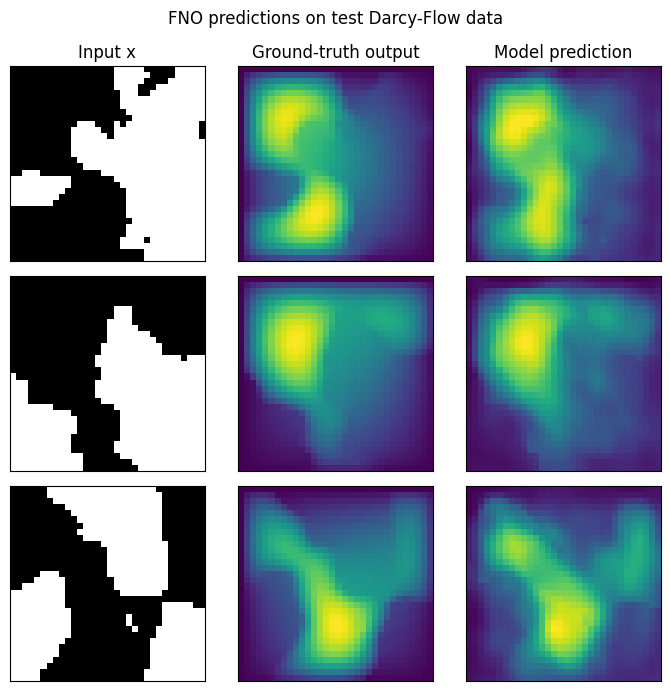

In [26]:
# Get predictions from the trained FNO on the stacked test set
fno_eval = problem_fno.nodes[0].cpu()  # ensure model on CPU for plotting
with torch.no_grad():
    preds = fno_eval(test_ds_fno.datadict)["y_fno"].cpu()

fig = plt.figure(figsize=(7, 7))
for index in range(3):
    sample = test_ds_fno[index]  # {'x_grid': ..., 'y_grid': ...}
    x = sample["x_grid"].cpu()
    y = sample["y_grid"].cpu()
    out = preds[index]  # model output from problem_fno

    ax = fig.add_subplot(3, 3, index * 3 + 1)
    ax.imshow(x[0], cmap="gray")
    if index == 0:
        ax.set_title("Input x")
    plt.xticks([], [])
    plt.yticks([], [])

    ax = fig.add_subplot(3, 3, index * 3 + 2)
    ax.imshow(y.squeeze())
    if index == 0:
        ax.set_title("Ground-truth output")
    plt.xticks([], [])
    plt.yticks([], [])

    ax = fig.add_subplot(3, 3, index * 3 + 3)
    ax.imshow(out.squeeze().detach().numpy())
    if index == 0:
        ax.set_title("Model prediction")
    plt.xticks([], [])
    plt.yticks([], [])

fig.suptitle("FNO predictions on test Darcy-Flow data", y=0.98)
plt.tight_layout()
fig.show()


### Testing on 16 x 16 dataset

In [27]:
# Example test loader (pick one resolution index)
res = 16  # 16 or 32
batch_size_test = 4
xs_t, ys_t = [], []
for i in range(len(dataset.test_dbs[res])):
    sample = dataset.data_processor.preprocess(dataset.test_dbs[res][i], batched=False)
    xs_t.append(sample["x"])
    ys_t.append(sample["y"].squeeze(0))  # [1, H, W]

x_test = torch.stack(xs_t)  # [N, 1, 16, 16]
y_test = torch.stack(ys_t)  # [N, 1, H, W]

test_ds_fno = DictDataset({"x_grid": x_test, "y_grid": y_test}, name=f"test{res}")
test_loader_fno = torch.utils.data.DataLoader(
    test_ds_fno,
    batch_size=batch_size_test,  # match your test batch size
    shuffle=False,
    collate_fn=test_ds_fno.collate_fn,
)

In [28]:
# evaluate trained FNO on test data
fno_out = problem_fno.nodes[0].cpu()
fno_model_out = fno_out(test_ds_fno.datadict)  # now on 32x32 grid

# evaluate forward pass on the train data
fno_model_out["y_fno"].shape

torch.Size([10, 1, 16, 16])

/tmp/ipykernel_263851/3574052000.py:36: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


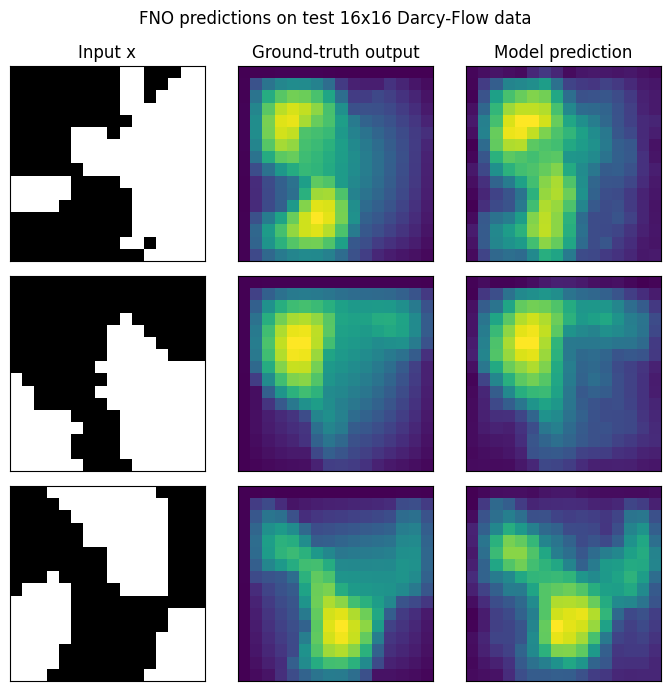

In [29]:
# Get predictions from the trained FNO on the stacked test set
fno_eval = problem_fno.nodes[0].cpu()  # ensure model on CPU for plotting
with torch.no_grad():
    preds = fno_eval(test_ds_fno.datadict)["y_fno"].cpu()

fig = plt.figure(figsize=(7, 7))
for index in range(3):
    sample = test_ds_fno[index]  # {'x_grid': ..., 'y_grid': ...}
    x = sample["x_grid"].cpu()
    y = sample["y_grid"].cpu()
    out = preds[index]  # model output from problem_fno

    ax = fig.add_subplot(3, 3, index * 3 + 1)
    ax.imshow(x[0], cmap="gray")
    if index == 0:
        ax.set_title("Input x")
    plt.xticks([], [])
    plt.yticks([], [])

    ax = fig.add_subplot(3, 3, index * 3 + 2)
    ax.imshow(y.squeeze())
    if index == 0:
        ax.set_title("Ground-truth output")
    plt.xticks([], [])
    plt.yticks([], [])

    ax = fig.add_subplot(3, 3, index * 3 + 3)
    ax.imshow(out.squeeze().detach().numpy())
    if index == 0:
        ax.set_title("Model prediction")
    plt.xticks([], [])
    plt.yticks([], [])

fig.suptitle("FNO predictions on test 16x16 Darcy-Flow data", y=0.98)
plt.tight_layout()
fig.show()
